# Dự báo tẩy trắng san hô quanh Lizard Island

Notebook này chỉ giữ phần chạy code, tạo bảng và vẽ biểu đồ. Toàn bộ phần giải thích, dẫn dắt bài học và hướng dẫn phân tích từng biểu đồ đã được tách sang file Markdown:

[coral_bleaching_forecast_lecture_guide.md](coral_bleaching_forecast_lecture_guide.md)

Các hình được xuất ra thư mục `reports/lecture_visuals`.

In [2]:

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as patches
import seaborn as sns

try:
    from IPython.display import display, Markdown
except ImportError:
    display = print
    Markdown = lambda text: text

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# Theme nhất quán cho bài giảng.
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 5),
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

PALETTE = {
    "blue": "#276FBF",
    "sky": "#5DADEC",
    "teal": "#2A9D8F",
    "green": "#6A994E",
    "yellow": "#F4A261",
    "orange": "#E76F51",
    "red": "#B23A48",
    "gray": "#6C757D",
    "light_gray": "#E9ECEF",
    "dark": "#253237",
}

ALERT_LABELS = {
    0: "No Stress",
    1: "Watch",
    2: "Warning",
    3: "Alert Level 1",
    4: "Alert Level 2",
}
ALERT_ORDER = list(ALERT_LABELS.keys())
ALERT_COLORS = {
    0: "#B7E4C7",
    1: "#FFD166",
    2: "#F4A261",
    3: "#E76F51",
    4: "#B23A48",
}
KEY_YEARS = [2016, 2017, 2024]


def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / "data" / "processed" / "node_features.csv").exists():
            return path
    raise FileNotFoundError("Không tìm thấy data/processed/node_features.csv từ thư mục hiện tại.")


ROOT = find_project_root()
DATA_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "lecture_visuals"
FIG_DIR.mkdir(parents=True, exist_ok=True)

node = pd.read_csv(DATA_DIR / "node_features.csv", parse_dates=["time", "target_time_h28"])
agg = pd.read_csv(DATA_DIR / "aggregate_features.csv", parse_dates=["time", "target_time_h28"])
nodes = pd.read_csv(DATA_DIR / "nodes.csv")

# Chuẩn hóa một vài cột để vẽ ổn định.
node["alert_level"] = node["alert_level"].astype(int)
agg["alert_level"] = agg["alert_level"].astype(int)
node["alert_label"] = node["alert_level"].map(ALERT_LABELS)
agg["alert_label"] = agg["alert_level"].map(ALERT_LABELS)
node["year"] = node["time"].dt.year
agg["year"] = agg["time"].dt.year
node["month"] = node["time"].dt.month
agg["month"] = agg["time"].dt.month

BASE_FEATURES = [
    "CRW_SST",
    "CRW_SSTANOMALY",
    "CRW_HOTSPOT",
    "CRW_DHW",
    "CRW_BAA",
    "CRW_BAA_7D_MAX",
]
TARGET_DHW = "target_CRW_DHW_h28"
TARGET_ALERT = "target_alert_level_h28"


def savefig(fig, name):
    path = FIG_DIR / name
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    return path

print(f"Project root: {ROOT}")
print(f"Node-level data: {node.shape[0]:,} rows, {node['node_id'].nunique()} grid cells")
print(f"Time range: {node['time'].min():%Y-%m-%d} to {node['time'].max():%Y-%m-%d}")
print(f"Figures will be saved to: {FIG_DIR}")


Project root: C:\Users\huynh\OneDrive\Máy tính\ThsHUIT\nGBR-DHW
Node-level data: 33,078 rows, 6 grid cells
Time range: 2010-01-01 to 2025-02-08
Figures will be saved to: C:\Users\huynh\OneDrive\Máy tính\ThsHUIT\nGBR-DHW\reports\lecture_visuals


## 0. Nạp dữ liệu và kiểm tra nhanh

Chạy cell bên dưới để xem kích thước dữ liệu, khoảng thời gian, các biến chính và tỷ lệ thiếu của nhãn dự báo 28 ngày. Phần diễn giải nằm trong file hướng dẫn Markdown.

In [2]:

valid_targets = node[[TARGET_DHW, TARGET_ALERT]].notna().all(axis=1).sum()
overview = pd.DataFrame([
    ("Nguồn chính", "NOAA Coral Reef Watch daily 5 km, đã xử lý trong repo"),
    ("Không gian", f"{node['node_id'].nunique()} ô lưới quanh Lizard Island"),
    ("Thời gian", f"{node['time'].min():%Y-%m-%d} đến {node['time'].max():%Y-%m-%d}"),
    ("Số dòng node-level", f"{len(node):,}"),
    ("Số ngày aggregate", f"{agg['time'].nunique():,}"),
    ("Đầu vào cốt lõi", ", ".join(BASE_FEATURES)),
    ("Đầu ra 1", f"{TARGET_DHW}: DHW sau 28 ngày"),
    ("Đầu ra 2", f"{TARGET_ALERT}: mức cảnh báo sau 28 ngày"),
    ("Dòng có đủ nhãn 28 ngày", f"{valid_targets:,} / {len(node):,}"),
], columns=["Hạng mục", "Giá trị"])

display(overview)

missing = (
    node[BASE_FEATURES + [TARGET_DHW, TARGET_ALERT]]
    .isna()
    .mean()
    .mul(100)
    .rename("Thiếu (%)")
    .reset_index()
    .rename(columns={"index": "Cột"})
)
missing["Thiếu (%)"] = missing["Thiếu (%)"].round(3)
display(missing)


,Hạng mục,Giá trị
0,Nguồn chính,"NOAA Coral Reef Watch daily 5 km, đã xử lý tro..."
1,Không gian,6 ô lưới quanh Lizard Island
2,Thời gian,2010-01-01 đến 2025-02-08
3,Số dòng node-level,"33,078"
4,Số ngày aggregate,"5,513"
5,Đầu vào cốt lõi,"CRW_SST, CRW_SSTANOMALY, CRW_HOTSPOT, CRW_DHW,..."
6,Đầu ra 1,target_CRW_DHW_h28: DHW sau 28 ngày
7,Đầu ra 2,target_alert_level_h28: mức cảnh báo sau 28 ngày
8,Dòng có đủ nhãn 28 ngày,"32,910 / 33,078"


,Cột,Thiếu (%)
0,CRW_SST,0.000
1,CRW_SSTANOMALY,0.000
2,CRW_HOTSPOT,0.000
3,CRW_DHW,0.000
4,CRW_BAA,0.000
5,CRW_BAA_7D_MAX,0.000
6,target_CRW_DHW_h28,0.508
7,target_alert_level_h28,0.508


## 1. Khung bài toán dự báo 28 ngày

Các cell trong phần này tạo hình minh họa bài toán hai đầu ra: dự báo DHW và dự báo mức cảnh báo tại `t + 28`.

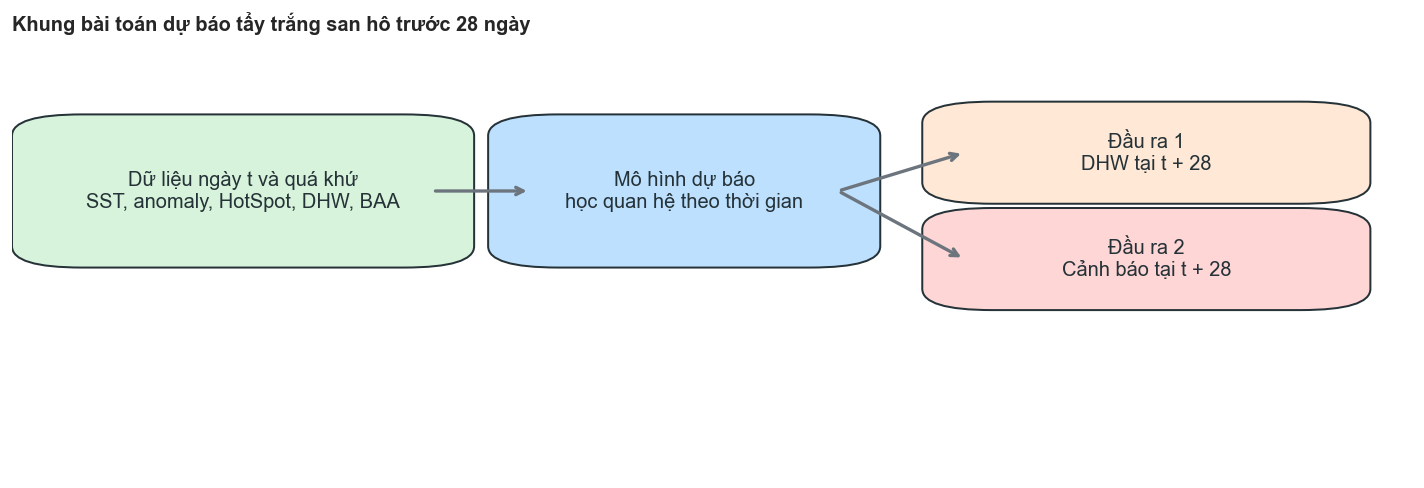

In [3]:

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.axis("off")


def box(x, y, w, h, text, color, fontsize=12):
    rect = patches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.05",
        facecolor=color,
        edgecolor=PALETTE["dark"],
        linewidth=1.2,
    )
    ax.add_patch(rect)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize, color=PALETTE["dark"], wrap=True)

box(0.03, 0.52, 0.27, 0.30, "Dữ liệu ngày t và quá khứ\nSST, anomaly, HotSpot, DHW, BAA", "#D8F3DC")
box(0.37, 0.52, 0.22, 0.30, "Mô hình dự báo\nhọc quan hệ theo thời gian", "#BDE0FE")
box(0.68, 0.67, 0.26, 0.18, "Đầu ra 1\nDHW tại t + 28", "#FFE8D6")
box(0.68, 0.42, 0.26, 0.18, "Đầu ra 2\nCảnh báo tại t + 28", "#FFD6D6")

arrow_kw = dict(arrowstyle="->", linewidth=2, color=PALETTE["gray"])
ax.annotate("", xy=(0.37, 0.67), xytext=(0.30, 0.67), arrowprops=arrow_kw)
ax.annotate("", xy=(0.68, 0.76), xytext=(0.59, 0.67), arrowprops=arrow_kw)
ax.annotate("", xy=(0.68, 0.51), xytext=(0.59, 0.67), arrowprops=arrow_kw)
ax.set_title("Khung bài toán dự báo tẩy trắng san hô trước 28 ngày", loc="left")
savefig(fig, "01_forecast_problem_diagram.png")
plt.show()


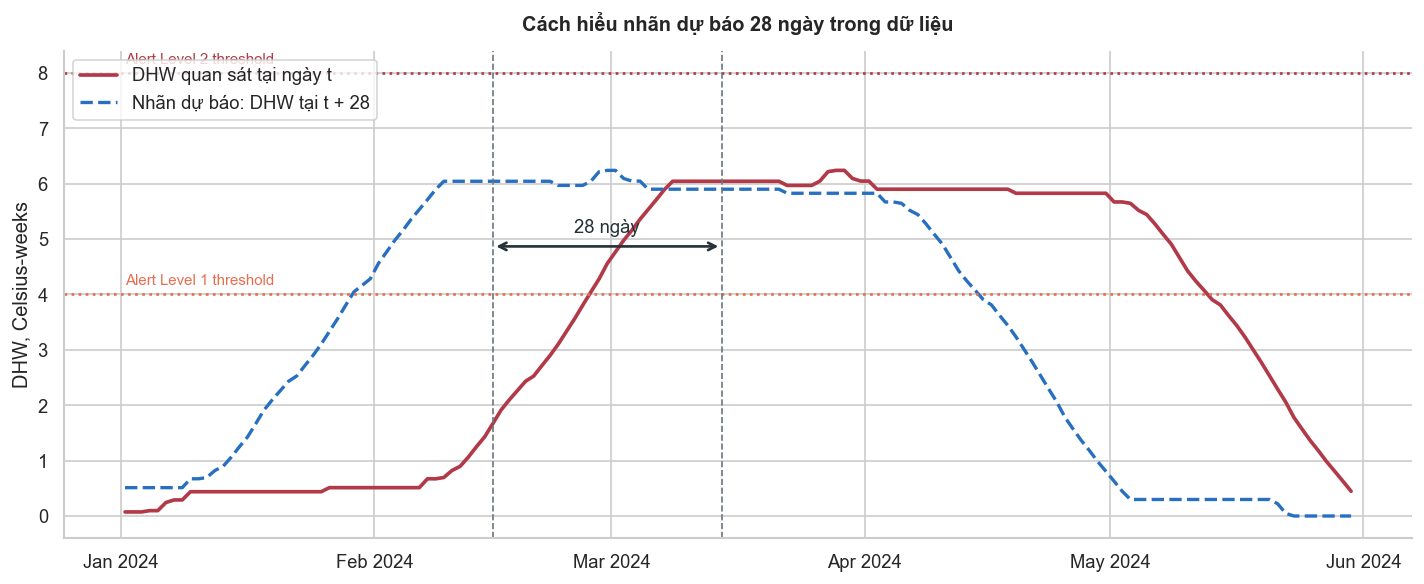

In [4]:

focus = agg[(agg["time"] >= "2024-01-01") & (agg["time"] <= "2024-05-31")].copy()
t0 = pd.Timestamp("2024-02-15 12:00:00")
row = agg.loc[(agg["time"] - t0).abs().idxmin()]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(focus["time"], focus["CRW_DHW"], color=PALETTE["red"], linewidth=2.2, label="DHW quan sát tại ngày t")
ax.plot(focus["time"], focus[TARGET_DHW], color=PALETTE["blue"], linewidth=2.0, linestyle="--", label="Nhãn dự báo: DHW tại t + 28")

for y, label, color in [(4, "Alert Level 1 threshold", PALETTE["orange"]), (8, "Alert Level 2 threshold", PALETTE["red"] )]:
    ax.axhline(y, color=color, linestyle=":", linewidth=1.6)
    ax.text(focus["time"].min(), y + 0.12, label, color=color, fontsize=9, va="bottom")

ax.axvline(row["time"], color=PALETTE["gray"], linestyle="--", linewidth=1)
ax.axvline(row["target_time_h28"], color=PALETTE["gray"], linestyle="--", linewidth=1)
y_arrow = max(0.8, focus[["CRW_DHW", TARGET_DHW]].max().max() * 0.78)
ax.annotate("", xy=(row["target_time_h28"], y_arrow), xytext=(row["time"], y_arrow), arrowprops=dict(arrowstyle="<->", color=PALETTE["dark"], linewidth=1.6))
ax.text(row["time"] + (row["target_time_h28"] - row["time"]) / 2, y_arrow + 0.25, "28 ngày", ha="center", color=PALETTE["dark"])

ax.set_title("Cách hiểu nhãn dự báo 28 ngày trong dữ liệu")
ax.set_ylabel("DHW, Celsius-weeks")
ax.set_xlabel("")
ax.legend(loc="upper left")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
savefig(fig, "02_28_day_target_alignment.png")
plt.show()


## 2. Bảng đặc trưng và minh họa biến

Các cell trong phần này tạo bảng ý nghĩa biến và các hình minh họa SST, anomaly, HotSpot, DHW, BAA, BAA 7-day max.

In [5]:

feature_dict = pd.DataFrame([
    ("CRW_SST", "Nhiệt độ mặt biển", "°C", "Nhiệt độ hôm nay", "Cho biết môi trường nước hiện tại nóng hay mát."),
    ("CRW_SSTANOMALY", "SST lệch so với bình thường", "°C", "Hôm nay nóng hơn bình thường bao nhiêu", "Phát hiện bất thường theo mùa, không chỉ nhiệt độ tuyệt đối."),
    ("CRW_HOTSPOT", "Mức vượt ngưỡng stress nhiệt", "°C", "Phần nhiệt độ vượt ngưỡng nguy hiểm", "Tín hiệu trực tiếp cho stress nhiệt hiện tại."),
    ("CRW_DHW", "Degree Heating Weeks", "°C-weeks", "Tổng số ngày nóng kéo dài quy đổi theo tuần", "Đo stress nhiệt tích lũy, thường liên quan mạnh đến tẩy trắng."),
    ("CRW_BAA", "Bleaching Alert Area", "0-4", "Đèn xanh, vàng, cam, đỏ cho rủi ro", "Nhãn cảnh báo dễ diễn giải cho quản lý và truyền thông."),
    ("CRW_BAA_7D_MAX", "BAA cao nhất trong 7 ngày", "0-4", "Mức cảnh báo cao nhất tuần vừa rồi", "Giữ ký ức ngắn hạn về đợt nóng hoặc cảnh báo vừa xảy ra."),
], columns=["Biến", "Ý nghĩa", "Đơn vị", "Ví dụ đời thường", "Vai trò trong dự báo"])

display(feature_dict)


,Biến,Ý nghĩa,Đơn vị,Ví dụ đời thường,Vai trò trong dự báo
0,CRW_SST,Nhiệt độ mặt biển,°C,Nhiệt độ hôm nay,Cho biết môi trường nước hiện tại nóng hay mát.
1,CRW_SSTANOMALY,SST lệch so với bình thường,°C,Hôm nay nóng hơn bình thường bao nhiêu,"Phát hiện bất thường theo mùa, không chỉ nhiệt..."
2,CRW_HOTSPOT,Mức vượt ngưỡng stress nhiệt,°C,Phần nhiệt độ vượt ngưỡng nguy hiểm,Tín hiệu trực tiếp cho stress nhiệt hiện tại.
3,CRW_DHW,Degree Heating Weeks,°C-weeks,Tổng số ngày nóng kéo dài quy đổi theo tuần,"Đo stress nhiệt tích lũy, thường liên quan mạn..."
4,CRW_BAA,Bleaching Alert Area,0-4,"Đèn xanh, vàng, cam, đỏ cho rủi ro",Nhãn cảnh báo dễ diễn giải cho quản lý và truy...
5,CRW_BAA_7D_MAX,BAA cao nhất trong 7 ngày,0-4,Mức cảnh báo cao nhất tuần vừa rồi,Giữ ký ức ngắn hạn về đợt nóng hoặc cảnh báo v...


### Minh họa DHW tích lũy

Cell bên dưới dùng ví dụ mô phỏng để trực quan hóa ý tưởng HotSpot từng ngày tích lũy thành DHW.

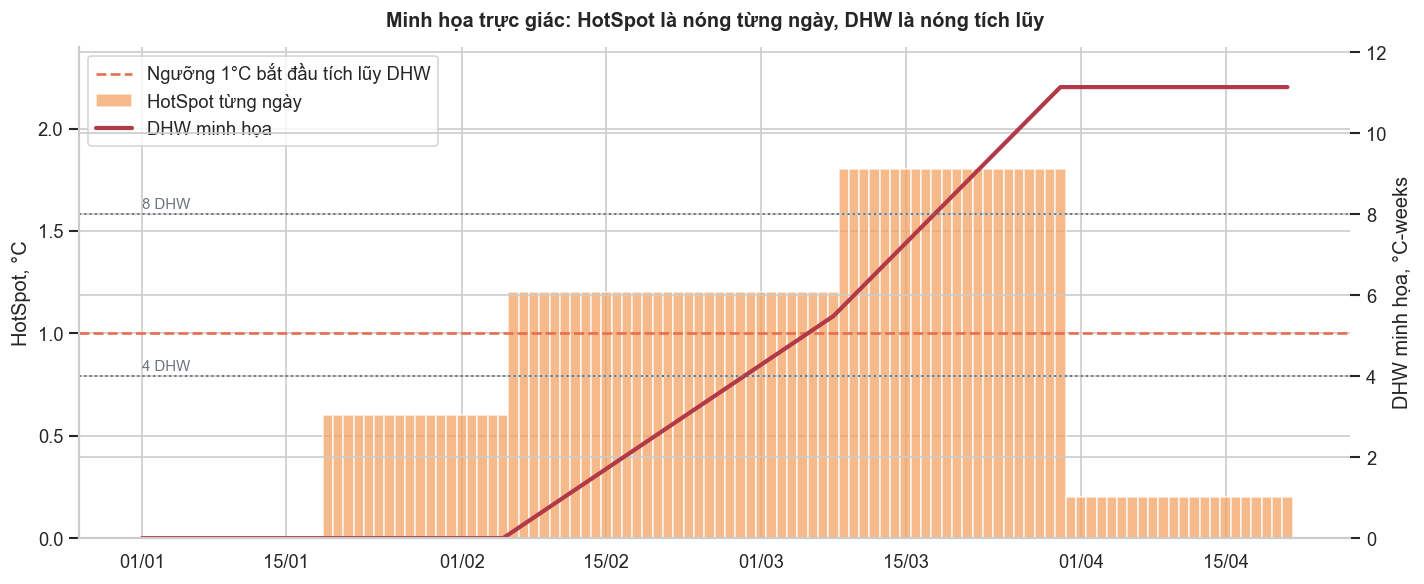

In [6]:

# Ví dụ mô phỏng để giải thích DHW. Đây là ví dụ sư phạm, không thay thế thuật toán NOAA đầy đủ.
days = pd.date_range("2024-01-01", periods=112, freq="D")
hotspot = np.zeros(len(days))
hotspot[18:36] = 0.6      # nóng nhẹ, dưới 1°C
hotspot[36:68] = 1.2      # vượt ngưỡng
hotspot[68:90] = 1.8      # vượt ngưỡng mạnh hơn
hotspot[90:] = 0.2        # giảm nhiệt
contributing_heat = np.where(hotspot >= 1.0, hotspot, 0.0)
toy_dhw = pd.Series(contributing_heat).rolling(84, min_periods=1).sum() / 7.0

toy = pd.DataFrame({"date": days, "HotSpot": hotspot, "DHW_minh_hoa": toy_dhw})

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(toy["date"], toy["HotSpot"], color=PALETTE["yellow"], alpha=0.75, width=1.0, label="HotSpot từng ngày")
ax1.axhline(1.0, color=PALETTE["orange"], linestyle="--", linewidth=1.6, label="Ngưỡng 1°C bắt đầu tích lũy DHW")
ax1.set_ylabel("HotSpot, °C")
ax1.set_ylim(0, 2.4)

ax2 = ax1.twinx()
ax2.plot(toy["date"], toy["DHW_minh_hoa"], color=PALETTE["red"], linewidth=2.5, label="DHW minh họa")
ax2.set_ylabel("DHW minh họa, °C-weeks")
ax2.set_ylim(0, max(8, toy["DHW_minh_hoa"].max() + 1))

for y, label in [(4, "4 DHW"), (8, "8 DHW")]:
    ax2.axhline(y, color=PALETTE["gray"], linestyle=":", linewidth=1.2)
    ax2.text(toy["date"].min(), y + 0.15, label, color=PALETTE["gray"], fontsize=9)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_title("Minh họa trực giác: HotSpot là nóng từng ngày, DHW là nóng tích lũy")
ax1.set_xlabel("")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
savefig(fig, "03_dhw_accumulation_intuition.png")
plt.show()


In [7]:

baa_table = pd.DataFrame([
    (0, "No Stress", "HotSpot <= 0", "Chưa có stress nhiệt đáng kể"),
    (1, "Watch", "0 < HotSpot < 1", "Có dấu hiệu nóng, nhưng chưa vượt ngưỡng cảnh báo chính"),
    (2, "Warning", "HotSpot >= 1 và DHW < 4", "Đang vượt ngưỡng nóng, cần theo dõi sát"),
    (3, "Alert Level 1", "HotSpot >= 1 và 4 <= DHW < 8", "Stress tích lũy đủ cao, nguy cơ tẩy trắng đáng kể"),
    (4, "Alert Level 2", "HotSpot >= 1 và DHW >= 8", "Stress rất cao, nguy cơ tẩy trắng nghiêm trọng"),
], columns=["BAA", "Tên mức", "Điều kiện diễn giải", "Ý nghĩa giảng dạy"])

display(baa_table)


,BAA,Tên mức,Điều kiện diễn giải,Ý nghĩa giảng dạy
0,0,No Stress,HotSpot <= 0,Chưa có stress nhiệt đáng kể
1,1,Watch,0 < HotSpot < 1,"Có dấu hiệu nóng, nhưng chưa vượt ngưỡng cảnh ..."
2,2,Warning,HotSpot >= 1 và DHW < 4,"Đang vượt ngưỡng nóng, cần theo dõi sát"
3,3,Alert Level 1,HotSpot >= 1 và 4 <= DHW < 8,"Stress tích lũy đủ cao, nguy cơ tẩy trắng đáng kể"
4,4,Alert Level 2,HotSpot >= 1 và DHW >= 8,"Stress rất cao, nguy cơ tẩy trắng nghiêm trọng"


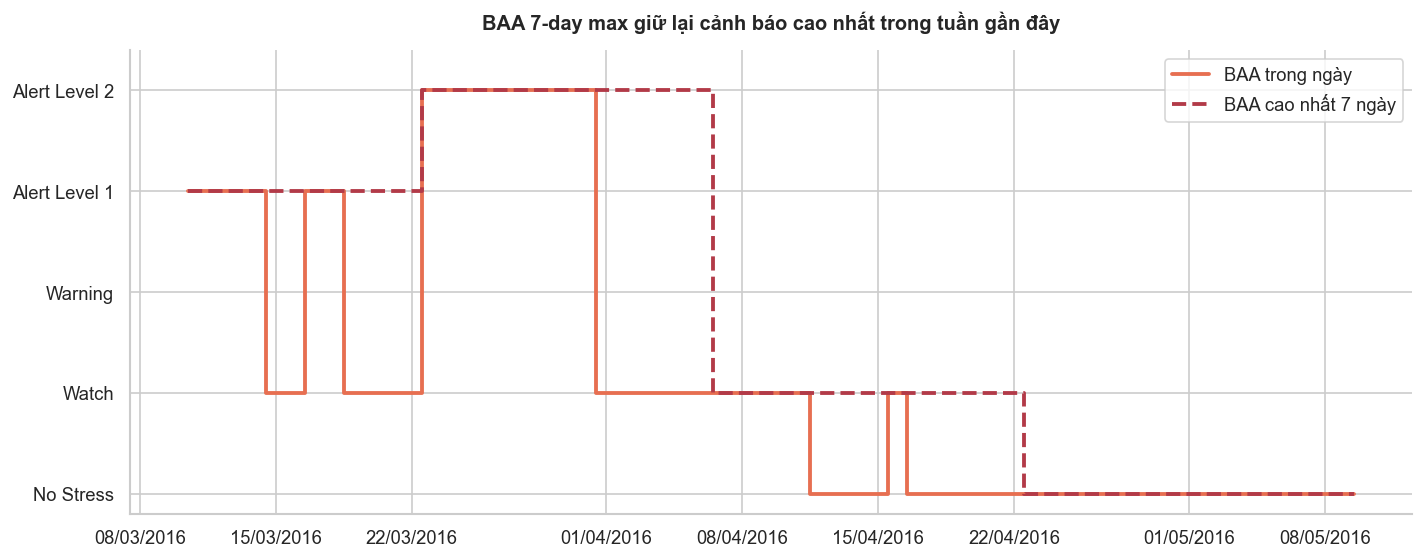

In [8]:

example = node[
    (node["node_id"] == 1)
    & (node["time"] >= "2016-03-10")
    & (node["time"] <= "2016-05-10")
].copy()

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.step(example["time"], example["CRW_BAA"], where="post", color=PALETTE["orange"], linewidth=2.3, label="BAA trong ngày")
ax.step(example["time"], example["CRW_BAA_7D_MAX"], where="post", color=PALETTE["red"], linewidth=2.3, linestyle="--", label="BAA cao nhất 7 ngày")
ax.set_yticks(ALERT_ORDER)
ax.set_yticklabels([ALERT_LABELS[i] for i in ALERT_ORDER])
ax.set_ylim(-0.2, 4.4)
ax.set_title("BAA 7-day max giữ lại cảnh báo cao nhất trong tuần gần đây")
ax.set_xlabel("")
ax.legend(loc="upper right")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%Y"))
savefig(fig, "04_baa_vs_7day_max.png")
plt.show()


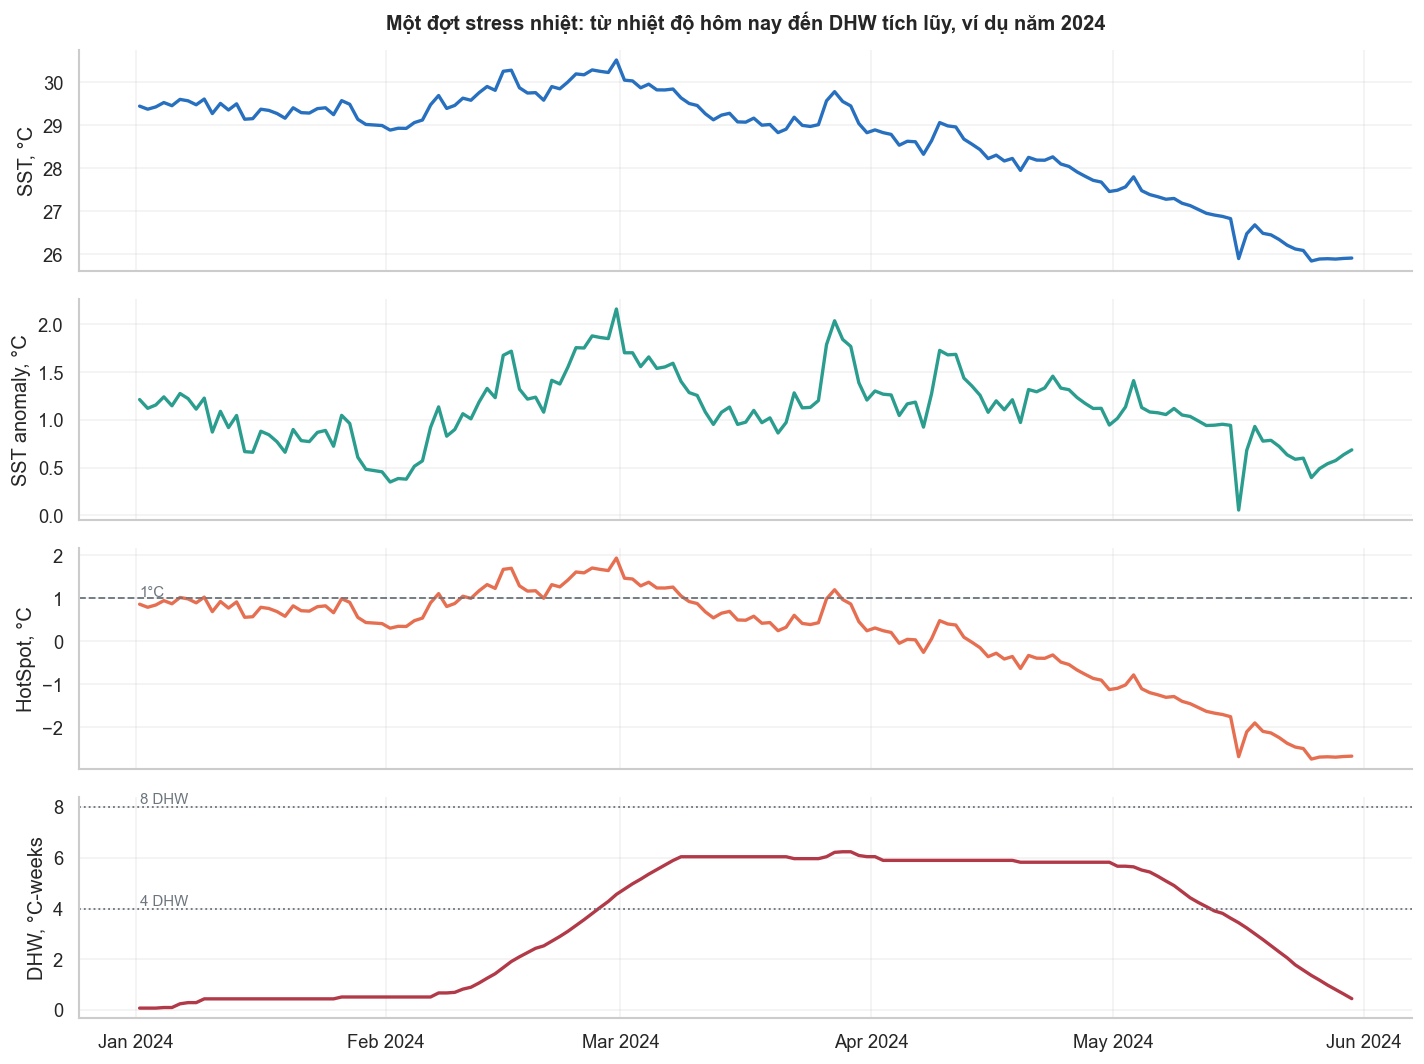

In [9]:

focus_2024 = agg[(agg["time"] >= "2024-01-01") & (agg["time"] <= "2024-05-31")].copy()
plot_specs = [
    ("CRW_SST", "SST, °C", PALETTE["blue"]),
    ("CRW_SSTANOMALY", "SST anomaly, °C", PALETTE["teal"]),
    ("CRW_HOTSPOT", "HotSpot, °C", PALETTE["orange"]),
    ("CRW_DHW", "DHW, °C-weeks", PALETTE["red"]),
]

fig, axes = plt.subplots(len(plot_specs), 1, figsize=(12, 9), sharex=True)
for ax, (col, label, color) in zip(axes, plot_specs):
    ax.plot(focus_2024["time"], focus_2024[col], color=color, linewidth=2.0)
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.25)
    if col == "CRW_HOTSPOT":
        ax.axhline(1, color=PALETTE["gray"], linestyle="--", linewidth=1.1)
        ax.text(focus_2024["time"].min(), 1.05, "1°C", color=PALETTE["gray"], fontsize=9)
    if col == "CRW_DHW":
        for y in [4, 8]:
            ax.axhline(y, color=PALETTE["gray"], linestyle=":", linewidth=1.1)
            ax.text(focus_2024["time"].min(), y + 0.12, f"{y} DHW", color=PALETTE["gray"], fontsize=9)

axes[0].set_title("Một đợt stress nhiệt: từ nhiệt độ hôm nay đến DHW tích lũy, ví dụ năm 2024")
axes[-1].set_xlabel("")
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
savefig(fig, "05_feature_progression_2024.png")
plt.show()


## 3. Trực quan dữ liệu

Các cell trong phần này tạo bản đồ 6 ô lưới, chuỗi DHW dài hạn, các năm stress nhiệt cao, phân bố lớp cảnh báo, quan hệ biến và mùa vụ.

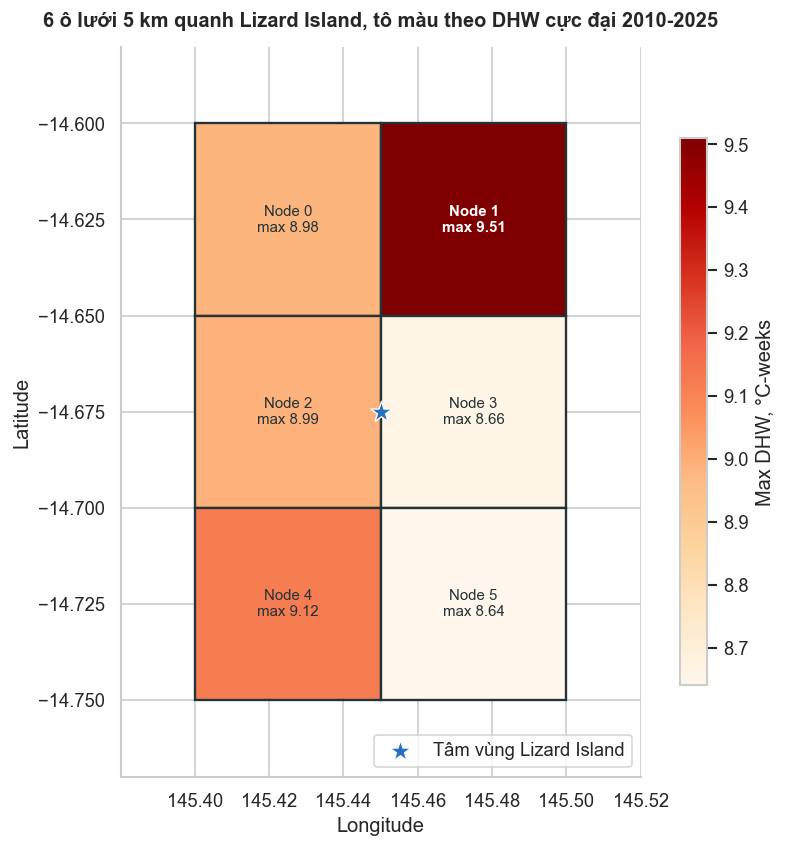

,node_id,latitude,longitude,max_dhw,mean_dhw,max_alert
0,0,-14.625,145.425,8.98,0.77,4
1,1,-14.625,145.475,9.51,0.79,4
2,2,-14.675,145.425,8.99,0.76,4
3,3,-14.675,145.475,8.66,0.75,4
4,4,-14.725,145.425,9.12,0.76,4
5,5,-14.725,145.475,8.64,0.76,4


In [10]:

node_summary = (
    node.groupby("node_id")
    .agg(
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        max_dhw=("CRW_DHW", "max"),
        mean_dhw=("CRW_DHW", "mean"),
        max_alert=("alert_level", "max"),
    )
    .reset_index()
)

lat_values = np.sort(nodes["latitude"].unique())
lon_values = np.sort(nodes["longitude"].unique())
lat_step = abs(np.diff(lat_values).mean()) if len(lat_values) > 1 else 0.05
lon_step = abs(np.diff(lon_values).mean()) if len(lon_values) > 1 else 0.05

fig, ax = plt.subplots(figsize=(7.2, 7.2))
norm = plt.Normalize(node_summary["max_dhw"].min(), node_summary["max_dhw"].max())
cmap = plt.cm.OrRd

for _, r in node_summary.iterrows():
    rect = patches.Rectangle(
        (r["longitude"] - lon_step / 2, r["latitude"] - lat_step / 2),
        lon_step,
        lat_step,
        facecolor=cmap(norm(r["max_dhw"])),
        edgecolor=PALETTE["dark"],
        linewidth=1.4,
    )
    ax.add_patch(rect)
    text_color = "white" if norm(r["max_dhw"]) > 0.65 else PALETTE["dark"]
    ax.text(
        r["longitude"],
        r["latitude"],
        f"Node {int(r['node_id'])}\nmax {r['max_dhw']:.2f}",
        ha="center",
        va="center",
        fontsize=9,
        color=text_color,
        fontweight="bold" if text_color == "white" else "normal",
    )

centroid_lon = nodes["longitude"].mean()
centroid_lat = nodes["latitude"].mean()
ax.scatter([centroid_lon], [centroid_lat], marker="*", s=180, color=PALETTE["blue"], edgecolor="white", linewidth=0.8, label="Tâm vùng Lizard Island")

pad_lon = lon_step * 0.9
pad_lat = lat_step * 0.9
ax.set_xlim(nodes["longitude"].min() - pad_lon, nodes["longitude"].max() + pad_lon)
ax.set_ylim(nodes["latitude"].min() - pad_lat, nodes["latitude"].max() + pad_lat)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("6 ô lưới 5 km quanh Lizard Island, tô màu theo DHW cực đại 2010-2025")
ax.legend(loc="lower right")
ax.set_aspect(1 / np.cos(np.deg2rad(centroid_lat)))
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
fig.colorbar(sm, ax=ax, shrink=0.75, label="Max DHW, °C-weeks")
savefig(fig, "06_lizard_island_grid_map.png")
plt.show()

# Bảng ngắn để giảng kèm bản đồ.
display(node_summary.round({"latitude": 3, "longitude": 3, "max_dhw": 2, "mean_dhw": 2}))


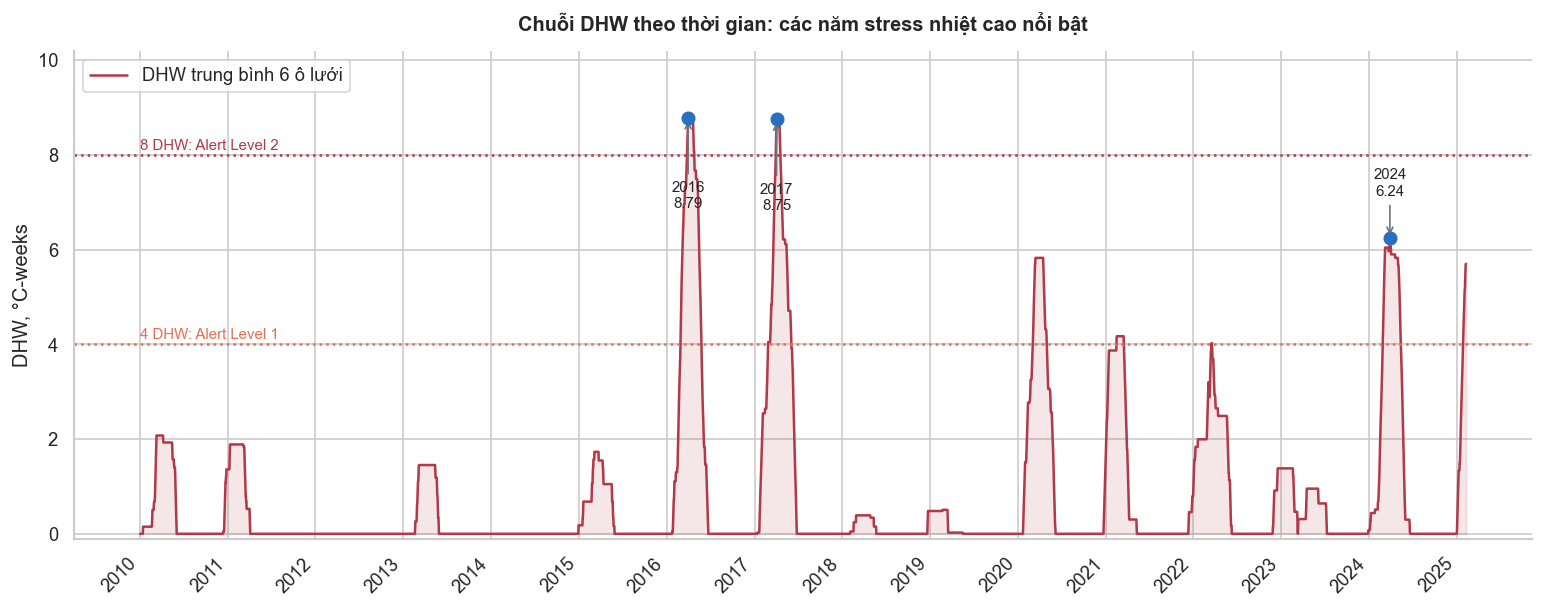

In [11]:

fig, ax = plt.subplots(figsize=(13, 5.2))
ax.plot(agg["time"], agg["CRW_DHW"], color=PALETTE["red"], linewidth=1.5, label="DHW trung bình 6 ô lưới")
ax.fill_between(agg["time"], agg["CRW_DHW"], color=PALETTE["red"], alpha=0.12)

for y, label, color in [(4, "4 DHW: Alert Level 1", PALETTE["orange"]), (8, "8 DHW: Alert Level 2", PALETTE["red"] )]:
    ax.axhline(y, color=color, linestyle=":", linewidth=1.5)
    ax.text(agg["time"].min(), y + 0.12, label, color=color, fontsize=9)

for year in KEY_YEARS:
    sub = agg[agg["year"] == year]
    peak = sub.loc[sub["CRW_DHW"].idxmax()]
    ax.scatter(peak["time"], peak["CRW_DHW"], s=55, color=PALETTE["blue"], zorder=5)
    offset = -38 if peak["CRW_DHW"] > 7.5 else 24
    ax.annotate(
        f"{year}\n{peak['CRW_DHW']:.2f}",
        xy=(peak["time"], peak["CRW_DHW"]),
        xytext=(0, offset),
        textcoords="offset points",
        ha="center",
        va="top" if offset < 0 else "bottom",
        arrowprops=dict(arrowstyle="->", color=PALETTE["gray"], linewidth=1),
        fontsize=9,
    )

ax.set_title("Chuỗi DHW theo thời gian: các năm stress nhiệt cao nổi bật")
ax.set_ylabel("DHW, °C-weeks")
ax.set_ylim(-0.1, max(10.2, agg["CRW_DHW"].max() + 1.4))
ax.set_xlabel("")
ax.legend(loc="upper left")
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
savefig(fig, "07_dhw_timeseries_key_years.png")
plt.show()


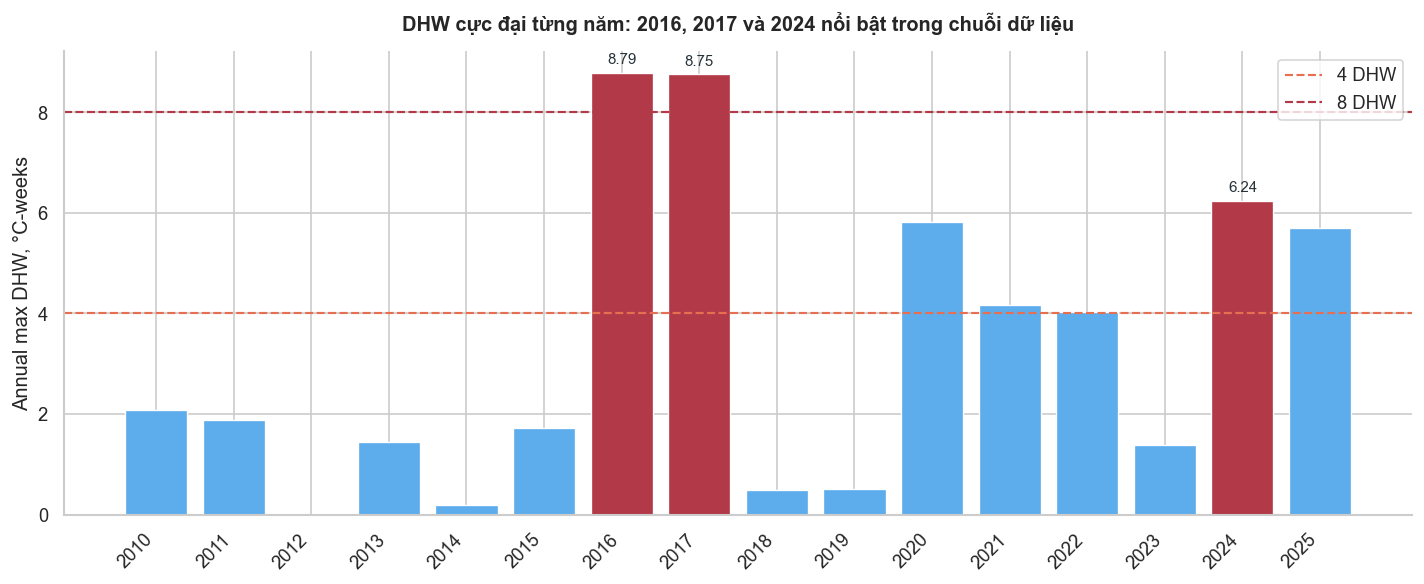

,year,max_dhw,mean_dhw,highlight
6,2016,8.787,2.016,Năm nhấn mạnh
7,2017,8.753,2.015,Năm nhấn mạnh
14,2024,6.238,1.473,Năm nhấn mạnh
10,2020,5.825,1.357,Năm khác
15,2025,5.698,2.949,Năm khác
11,2021,4.172,0.972,Năm khác
12,2022,4.025,1.100,Năm khác
0,2010,2.075,0.522,Năm khác
1,2011,1.887,0.390,Năm khác
5,2015,1.730,0.397,Năm khác


In [12]:

annual = (
    agg.groupby("year", as_index=False)
    .agg(max_dhw=("CRW_DHW", "max"), mean_dhw=("CRW_DHW", "mean"))
)
annual["highlight"] = np.where(annual["year"].isin(KEY_YEARS), "Năm nhấn mạnh", "Năm khác")

fig, ax = plt.subplots(figsize=(12, 5))
colors = [PALETTE["red"] if y in KEY_YEARS else PALETTE["sky"] for y in annual["year"]]
ax.bar(annual["year"].astype(str), annual["max_dhw"], color=colors, edgecolor="white", linewidth=0.8)
ax.axhline(4, color=PALETTE["orange"], linestyle="--", linewidth=1.3, label="4 DHW")
ax.axhline(8, color=PALETTE["red"], linestyle="--", linewidth=1.3, label="8 DHW")

for _, r in annual[annual["year"].isin(KEY_YEARS)].iterrows():
    ax.text(str(int(r["year"])), r["max_dhw"] + 0.18, f"{r['max_dhw']:.2f}", ha="center", fontsize=9, color=PALETTE["dark"])

ax.set_title("DHW cực đại từng năm: 2016, 2017 và 2024 nổi bật trong chuỗi dữ liệu")
ax.set_ylabel("Annual max DHW, °C-weeks")
ax.set_xlabel("")
ax.legend(loc="upper right")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
savefig(fig, "08_annual_max_dhw.png")
plt.show()

display(annual.sort_values("max_dhw", ascending=False).head(10).round(3))


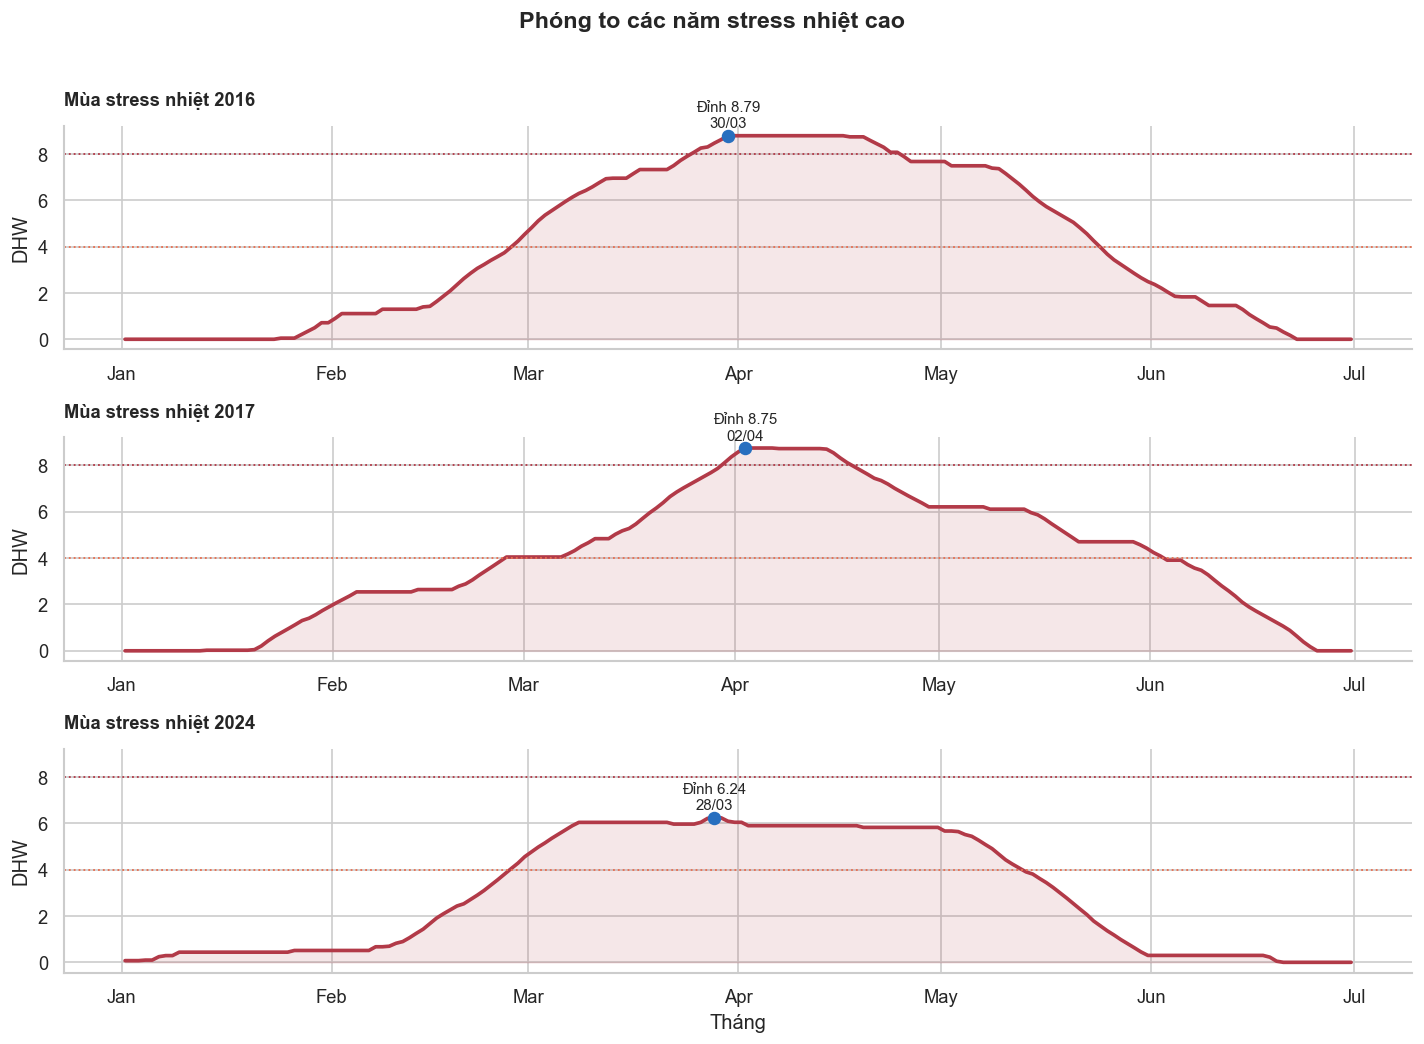

In [13]:

fig, axes = plt.subplots(len(KEY_YEARS), 1, figsize=(12, 8.5), sharex=False, sharey=True)
for ax, year in zip(axes, KEY_YEARS):
    sub = agg[(agg["year"] == year) & (agg["month"].between(1, 6))]
    ax.plot(sub["time"], sub["CRW_DHW"], color=PALETTE["red"], linewidth=2.2)
    ax.fill_between(sub["time"], sub["CRW_DHW"], color=PALETTE["red"], alpha=0.12)
    for y, color in [(4, PALETTE["orange"]), (8, PALETTE["red"] )]:
        ax.axhline(y, color=color, linestyle=":", linewidth=1.1)
    peak = sub.loc[sub["CRW_DHW"].idxmax()]
    ax.scatter(peak["time"], peak["CRW_DHW"], color=PALETTE["blue"], s=50, zorder=5)
    ax.text(peak["time"], peak["CRW_DHW"] + 0.35, f"Đỉnh {peak['CRW_DHW']:.2f}\n{peak['time']:%d/%m}", ha="center", fontsize=9)
    ax.set_title(f"Mùa stress nhiệt {year}", loc="left", fontsize=11)
    ax.set_ylabel("DHW")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

axes[-1].set_xlabel("Tháng")
fig.suptitle("Phóng to các năm stress nhiệt cao", y=1.02, fontsize=14, fontweight="bold")
savefig(fig, "09_key_years_zoom.png")
plt.show()


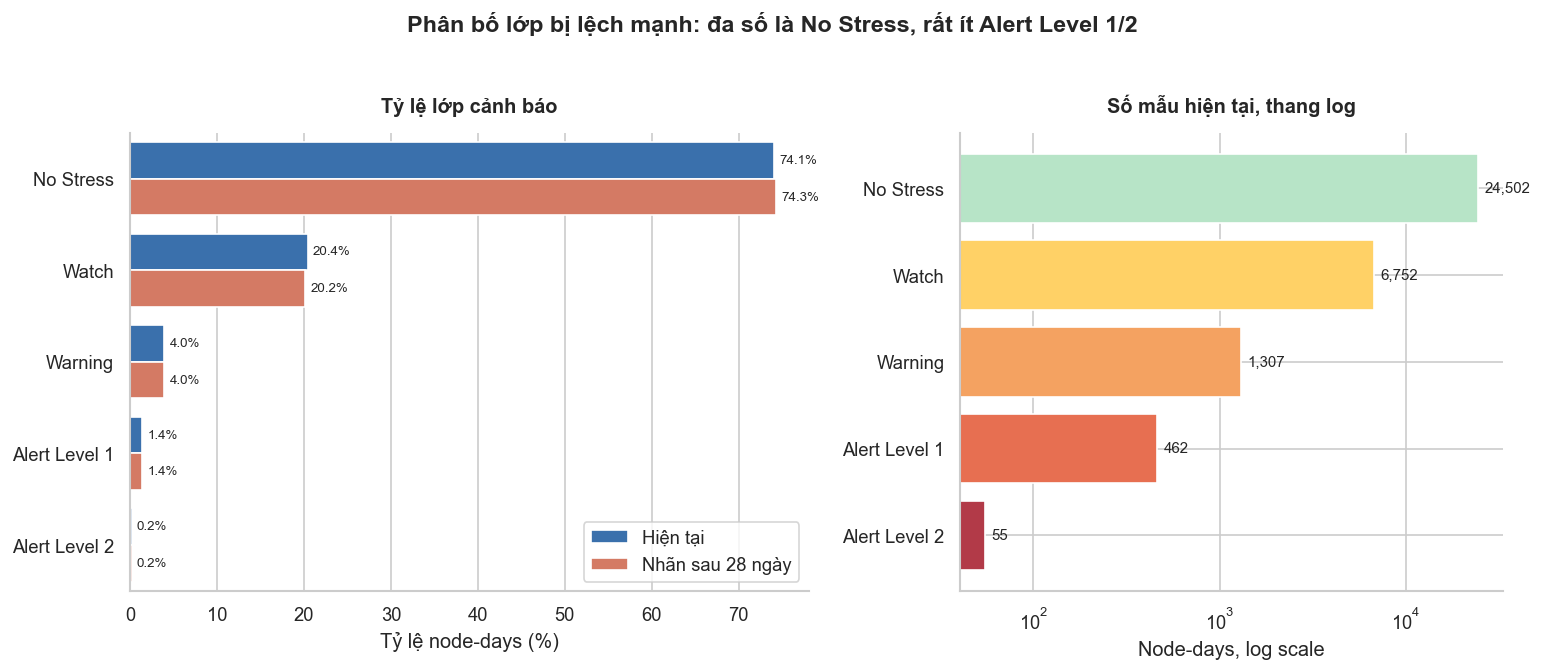

,dataset,alert_level,alert_label,count,percent
0,Hiện tại,0,No Stress,24502,74.07
1,Hiện tại,1,Watch,6752,20.41
2,Hiện tại,2,Warning,1307,3.95
3,Hiện tại,3,Alert Level 1,462,1.40
4,Hiện tại,4,Alert Level 2,55,0.17
5,Nhãn sau 28 ngày,0,No Stress,24459,74.32
6,Nhãn sau 28 ngày,1,Watch,6633,20.15
7,Nhãn sau 28 ngày,2,Warning,1301,3.95
8,Nhãn sau 28 ngày,3,Alert Level 1,462,1.40
9,Nhãn sau 28 ngày,4,Alert Level 2,55,0.17


In [14]:

def alert_distribution(series, name):
    clean = series.dropna().astype(int)
    counts = clean.value_counts().reindex(ALERT_ORDER, fill_value=0)
    return pd.DataFrame({
        "dataset": name,
        "alert_level": ALERT_ORDER,
        "alert_label": [ALERT_LABELS[i] for i in ALERT_ORDER],
        "count": counts.values,
        "percent": counts.values / counts.values.sum() * 100,
    })

dist = pd.concat([
    alert_distribution(node["alert_level"], "Hiện tại"),
    alert_distribution(node[TARGET_ALERT], "Nhãn sau 28 ngày"),
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.4), gridspec_kw={"width_ratios": [1.25, 1]})

sns.barplot(
    data=dist,
    y="alert_label",
    x="percent",
    hue="dataset",
    order=[ALERT_LABELS[i] for i in ALERT_ORDER],
    ax=axes[0],
    palette=[PALETTE["blue"], PALETTE["orange"]],
)
axes[0].set_title("Tỷ lệ lớp cảnh báo")
axes[0].set_xlabel("Tỷ lệ node-days (%)")
axes[0].set_ylabel("")
axes[0].legend(title="")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)

obs = dist[dist["dataset"] == "Hiện tại"].copy()
axes[1].barh(obs["alert_label"], obs["count"], color=[ALERT_COLORS[i] for i in obs["alert_level"]])
axes[1].set_xscale("log")
axes[1].set_title("Số mẫu hiện tại, thang log")
axes[1].set_xlabel("Node-days, log scale")
axes[1].invert_yaxis()
for _, r in obs.iterrows():
    axes[1].text(r["count"] * 1.08, r["alert_label"], f"{int(r['count']):,}", va="center", fontsize=9)

fig.suptitle("Phân bố lớp bị lệch mạnh: đa số là No Stress, rất ít Alert Level 1/2", y=1.03, fontsize=14, fontweight="bold")
savefig(fig, "10_alert_distribution_imbalance.png")
plt.show()

display(dist.assign(percent=lambda d: d["percent"].round(2)))


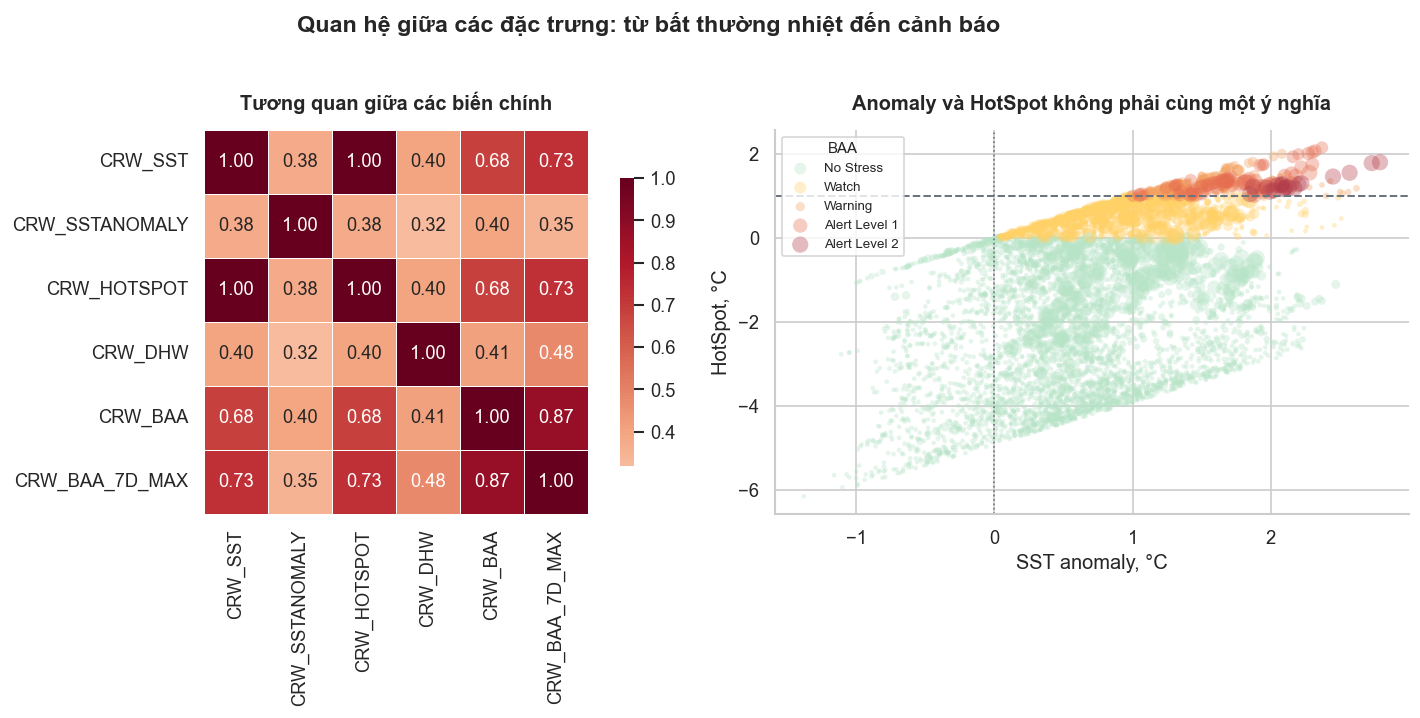

In [15]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

corr = node[BASE_FEATURES].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, linewidths=0.5, ax=axes[0], cbar_kws={"shrink": 0.75})
axes[0].set_title("Tương quan giữa các biến chính")

sample = node.sample(min(6000, len(node)), random_state=42)
for level in ALERT_ORDER:
    part = sample[sample["alert_level"] == level]
    axes[1].scatter(
        part["CRW_SSTANOMALY"],
        part["CRW_HOTSPOT"],
        s=np.clip(part["CRW_DHW"] * 11 + 8, 8, 95),
        alpha=0.35,
        color=ALERT_COLORS[level],
        label=ALERT_LABELS[level],
        edgecolors="none",
    )
axes[1].axhline(1, color=PALETTE["gray"], linestyle="--", linewidth=1.2)
axes[1].axvline(0, color=PALETTE["gray"], linestyle=":", linewidth=1.0)
axes[1].set_title("Anomaly và HotSpot không phải cùng một ý nghĩa")
axes[1].set_xlabel("SST anomaly, °C")
axes[1].set_ylabel("HotSpot, °C")
axes[1].legend(title="BAA", fontsize=8, title_fontsize=9, loc="upper left", frameon=True)

fig.suptitle("Quan hệ giữa các đặc trưng: từ bất thường nhiệt đến cảnh báo", y=1.03, fontsize=14, fontweight="bold")
savefig(fig, "11_feature_relationships.png")
plt.show()


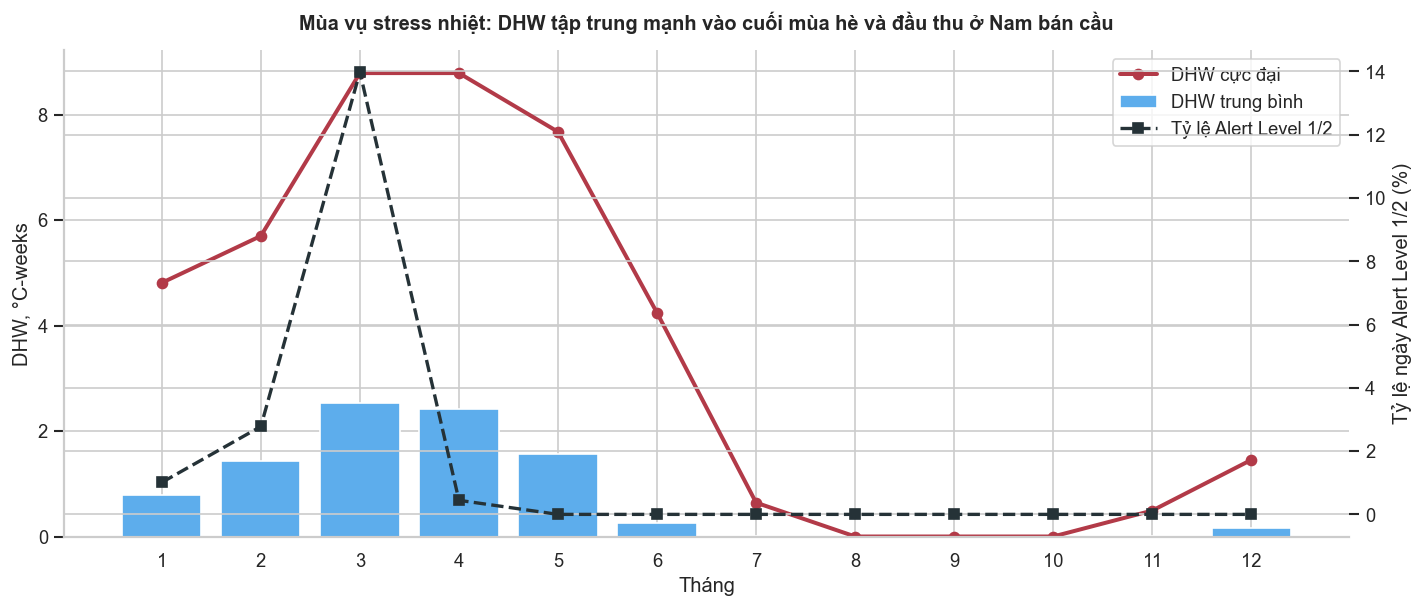

,month,mean_dhw,max_dhw,mean_sst,alert_event_pct
0,1,0.794,4.810,29.055,1.010
1,2,1.439,5.698,29.123,2.778
2,3,2.524,8.787,28.943,13.978
3,4,2.422,8.787,27.953,0.444
4,5,1.571,7.673,26.519,0.000
5,6,0.262,4.240,25.256,0.000
6,7,0.010,0.642,24.607,0.000
7,8,0.000,0.000,24.552,0.000
8,9,0.000,0.000,25.105,0.000
9,10,0.000,0.000,26.140,0.000


In [16]:

monthly = (
    agg.assign(alert_event=lambda d: d["alert_level"].ge(3))
    .groupby("month", as_index=False)
    .agg(
        mean_dhw=("CRW_DHW", "mean"),
        max_dhw=("CRW_DHW", "max"),
        mean_sst=("CRW_SST", "mean"),
        alert_event_pct=("alert_event", lambda s: s.mean() * 100),
    )
)

fig, ax1 = plt.subplots(figsize=(12, 5.2))
ax1.bar(monthly["month"], monthly["mean_dhw"], color=PALETTE["sky"], label="DHW trung bình")
ax1.plot(monthly["month"], monthly["max_dhw"], color=PALETTE["red"], linewidth=2.4, marker="o", label="DHW cực đại")
ax1.set_ylabel("DHW, °C-weeks")
ax1.set_xlabel("Tháng")
ax1.set_xticks(range(1, 13))

ax2 = ax1.twinx()
ax2.plot(monthly["month"], monthly["alert_event_pct"], color=PALETTE["dark"], linewidth=2.0, marker="s", linestyle="--", label="Tỷ lệ Alert Level 1/2")
ax2.set_ylabel("Tỷ lệ ngày Alert Level 1/2 (%)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
ax1.set_title("Mùa vụ stress nhiệt: DHW tập trung mạnh vào cuối mùa hè và đầu thu ở Nam bán cầu")
savefig(fig, "12_monthly_seasonality.png")
plt.show()

display(monthly.round(3))


## Tài liệu giải thích

Xem file [coral_bleaching_forecast_lecture_guide.md](coral_bleaching_forecast_lecture_guide.md) để đọc phần giải thích đầy đủ và hướng dẫn phân tích từng biểu đồ cho học sinh.